# End-to-End Cancer Mutation Classification Pipeline
This notebook combines Data Preprocessing, Exploratory Data Analysis (EDA), Evaluation Tooling, and Baseline Modeling into a single, functional, top-to-bottom master pipeline.

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm shap statsmodels jupyter

                  -`
                 .o+`
                `ooo/
               `+oooo:
              `+oooooo:
              -+oooooo+:
            `/:-:++oooo+:
           `/++++/+++++++:
          `/++++++++++++++:
         `/+++ooooooooooooo/`
        ./ooosssso++osssssso+`
       .oossssso-````/ossssss+`
      -osssssso.      :ssssssso.
     :osssssss/        osssso+++.
    /ossssssss/        +ssssooo/-
  `/ossssso+/:-        -:/+osssso+-
 `+sso+:-`                 `.-/+oso:
`++:.                           `-/+/
.`                                 `/arjun@bhondupc
--------------
OS: Arch Linux x86_64
Host: ASUS TUF Gaming F15 FX507VV_FX507VV (1.0)
Kernel: Linux 6.19.9-arch1-1
Uptime: 4 hours, 3 mins
Packages: 1461 (pacman), 8 (flatpak)
Shell: fish 4.5.0
Display (NE156FHM-NX6): 1920x1080 in 16", 144 Hz [Built-in]
DE: KDE Plasma 6.6.3
WM: KWin (Wayland)
WM Theme: Ant-Dark
Theme: Oxygen (Ant-Dark) [Qt], Breeze-Dark [GTK2], Breeze [GTK3/4]
Icons: Ant-Dark [Qt], Ant-Dark [GTK2/3/4]
Font

# Stage 1: Data Preprocessing
In this stage, we load the massive raw COSMIC databases, filter for somatic protein-altering mutations, and merge them with the Cancer Gene Census (CGC) to create our exact prediction targets.

### **Cell 1: Base Imports**
* Initializes the notebook by importing the powerful `pandas` library, the primary tool used for processing and structuring massive raw datasets.

In [9]:
import pandas as pd

### **Cell 2: Core Data Filtering & Chunking**
* **Memory Management:** The raw COSMIC mutation database is too excessively large to load entirely into memory. This cell loops through the file in highly optimized 100,000-row `chunks`.
* **Somatic Filter:** Strictly filters the data to keep only rows verified as a `'Confirmed somatic variant'`, ensuring we aren't training on inherited germline mutations.
* **Consequence Filter:** Curates the dataset to specifically focus on protein-altering mutations (like `missense`, `frameshift`, and `stop_gained`), dropping structural blanks.
* **Exporting:** Consecutively writes the filtered, streamlined chunks into a brand new file `clean_GSM.tsv`.

In [ ]:
import os

# WORKAROUND: Skip data processing if the 12GB raw data files are missing,
# since the preprocessed versions are already provided in the repository.
raw_data_path = 'raw data/Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'
raw_data_path_win = 'raw data/Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'

if os.path.exists(raw_data_path) or os.path.exists(raw_data_path_win):
    #CLEANING THE RAW GSM FOR ONLY DESIRED VALUES
    
    
    
    input_file = 'raw data/Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'
    output_file = 'preprocessed data/clean_GSM.tsv'
    
    # reader = pd.read_csv(
    #     input_file,
    #     sep='\t',
    #     chunksize=100000
    # )
    
    # chunk = next(reader)
    
    # print(chunk.columns.tolist())
    # print(chunk.head(3))
    
    columns_to_keep = [
        "GENE_SYMBOL",
        "MUTATION_AA",
        "MUTATION_DESCRIPTION",
        "GENOMIC_WT_ALLELE",
        "GENOMIC_MUT_ALLELE",
        "CHROMOSOME",
        "GENOME_START",
        "MUTATION_SOMATIC_STATUS"
    ]
    
    first_chunk = True
    chunk_size = 100000
    
    for chunk in pd.read_csv(input_file, sep='\t', chunksize=chunk_size, usecols=columns_to_keep, low_memory=True):
    
        # filter somatic
        chunk = chunk[
            chunk["MUTATION_SOMATIC_STATUS"] == "Confirmed somatic variant"
        ]
    
        # filter protein-altering consequences
        chunk = chunk[
            chunk["MUTATION_DESCRIPTION"].str.contains(
                "missense_variant|stop_gained|frameshift_variant|splice|inframe",
                na=False
            )
        ]
    
        # drop somatic column
        chunk = chunk.drop(columns=["MUTATION_SOMATIC_STATUS"])
    
        #write or append the chunk
        if first_chunk:
            chunk.to_csv(output_file, sep='\t', index=False, mode='w')
            first_chunk = False
        else:
            chunk.to_csv(output_file, sep='\t', index=False, mode='a', header=False)
    print("Data filtered succesfully....")
else:
    print('Skipping this step because the massive 12GB raw datasets are missing.')
    print('This is expected. We will rely on the preprocessed files directly.')
#havent tested after the workaround, i need to sleep TT 

FileNotFoundError: [Errno 2] No such file or directory: 'raw data\\Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'

### **Cell 3: Loading the Label Reference Key**
* **CGC Database:** Loads the official Cancer Gene Census (CGC) database. This acts as our source of truth or 'Answer Key', identifying exactly which genes are proven cancer drivers.
* **Cleaning:** Trims off any invisible trailing spaces in the gene names to prevent string-matching errors during merging, and explicitly drops any duplicate gene references to create a pure relational subset.

In [ ]:
import os

# WORKAROUND: Skip data processing if the 12GB raw data files are missing,
# since the preprocessed versions are already provided in the repository.
raw_data_path = 'raw data/Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'
raw_data_path_win = 'raw data/Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'

if os.path.exists(raw_data_path) or os.path.exists(raw_data_path_win):
    cgc_file_path = 'raw data/Cosmic_CancerGeneCensus_v103_GRCh37.tsv'
    output_file = 'preprocessed data/clean_GSM.tsv'
    clean_gsm = pd.read_csv(output_file, sep='\t')
    cgc_file = pd.read_csv(cgc_file_path, sep='\t')
    
    #filter the cgc file and remove duplicates
    cgc_subset = cgc_file[[
        "GENE_SYMBOL",
        "ROLE_IN_CANCER",
        "TIER"
    ]].drop_duplicates(subset=["GENE_SYMBOL"])
    
    #remove tailing spaces 
    cgc_subset["GENE_SYMBOL"] = cgc_subset["GENE_SYMBOL"].str.strip()
    
    print("Data filtered succesfully....")
else:
    print('Skipping this step because the massive 12GB raw datasets are missing.')
    print('This is expected. We will rely on the preprocessed files directly.')


Data filtered succesfully....


### **Cell 4: Final Merging & Target Generation**
* **Relational Mapping:** Reads the filtered GSM file in chunks again and does a `Left Merge` with the CGC reference table based strictly on the `GENE_SYMBOL`.
* **Creating the Labels (The Target):** It generates the critical `is_CGC` binary column. If a mutation maps to a known cancer gene in the CGC reference, it flags it `1` (Driver). If not, it becomes `0` (Passenger).
* **Testing:** Appends everything neatly into the master file `gsm_clean_with_cgc.tsv` and runs a tiny 10,000-row test query to verify the merging logic functioned properly.

In [ ]:
import os

# WORKAROUND: Skip data processing if the 12GB raw data files are missing,
# since the preprocessed versions are already provided in the repository.
raw_data_path = 'raw data/Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'
raw_data_path_win = 'raw data/Cosmic_GenomeScreensMutant_v103_GRCh37.tsv'

if os.path.exists(raw_data_path) or os.path.exists(raw_data_path_win):
    input_file = 'preprocessed data/clean_GSM.tsv'        
    output_file = "preprocessed data/gsm_clean_with_cgc.tsv"
    
    chunk_size = 100000
    first_chunk = True
    
    for chunk in pd.read_csv(
        input_file,
        sep='\t',
        chunksize=chunk_size,
        low_memory=True
    ):
    
        # clean gene symbol
        chunk["GENE_SYMBOL"] = chunk["GENE_SYMBOL"].str.strip()
    
        # merge CGC
        chunk = chunk.merge(
            cgc_subset,
            on="GENE_SYMBOL",
            how="left"
        )
    
        # create CGC flag
        chunk["is_CGC"] = chunk["ROLE_IN_CANCER"].notna().astype(int)
    
        # write to disk
        if first_chunk:
            chunk.to_csv(output_file, sep='\t', index=False, mode='w')
            first_chunk = False
        else:
            chunk.to_csv(output_file, sep='\t', index=False, mode='a', header=False)
    
    print("Finished merging CGC.")
    
    #merge test
    test = pd.read_csv(output_file, sep='\t', nrows=10000)
    print(test["is_CGC"].value_counts())
else:
    print('Skipping this step because the massive 12GB raw datasets are missing.')
    print('This is expected. We will rely on the preprocessed files directly.')


Finished merging CGC.
is_CGC
0    9070
1     930
Name: count, dtype: int64


# Stage 2: Exploratory Data Analysis (EDA)
Here we analyze the filtered data visually to understand the immense class imbalances, top mutation types, and the most frequently mutated genes.

### **Cell 1: Environment Setup**
* **Imports:** Prepares the workspace for Exploratory Data Analysis (EDA) by importing `pandas` for handling the data and `matplotlib` for generating the visual graphs.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


### **Cell 2: Memory-Optimized Ingestion**
* **Selective Loading:** To prevent the notebook from crashing, it specifically imports *only* the three columns (`GENE_SYMBOL`, `MUTATION_DESCRIPTION`, `is_CGC`) required for these high-level descriptive charts.
* Prints the final 13-million-plus shape of the data.

In [ ]:
input_file = "preprocessed data/gsm_clean_with_cgc.tsv"

cols_needed = [
    "GENE_SYMBOL",
    "MUTATION_DESCRIPTION",
    "is_CGC"
]

df = pd.read_csv(
    input_file,
    sep="\t",
    usecols=cols_needed
)

print(df.shape)

(13617032, 3)


### **Cell 3: Class Imbalance Visualization**
* **The Target Ratio:** Uses `value_counts()` and bar charts to visually expose the overwhelming fundamental challenge of this project: the massive disparity between common Non-CGC (Passenger) anomalies versus rare, lethal CGC (Driver) samples.

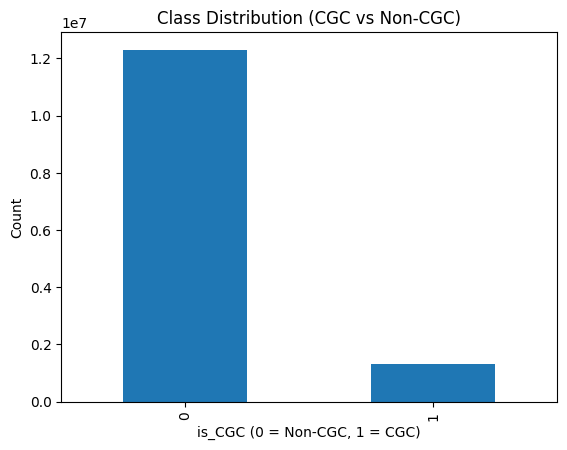

In [ ]:
#class distribution plot

class_counts = df["is_CGC"].value_counts()

plt.figure()
class_counts.plot(kind="bar")
plt.title("Class Distribution (CGC vs Non-CGC)")
plt.xlabel("is_CGC (0 = Non-CGC, 1 = CGC)")
plt.ylabel("Count")
plt.show()

### **Cell 4: The Most Common Mutation Styles**
* **Logarithmic Spread:** Extracts the top 10 biological mutation triggers (e.g. missense, intronic, frameshift) and maps them. It intentionally plots them on a `log` scale Y-axis, so extremely dominant mutation types don't squash the smaller ones into invisibility.

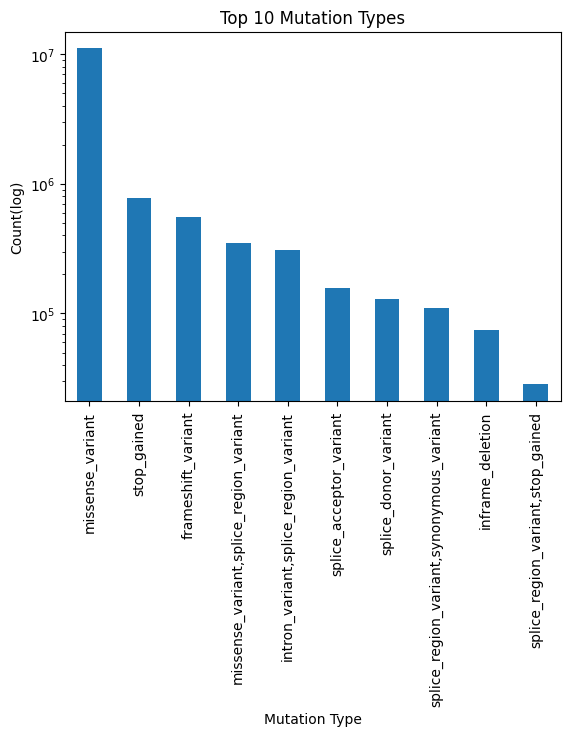

In [ ]:
#mutation type plot

mutation_counts = df["MUTATION_DESCRIPTION"].value_counts().head(10)

plt.figure()
mutation_counts.plot(kind="bar")
plt.title("Top 10 Mutation Types")
plt.xlabel("Mutation Type")
plt.ylabel("Count(log)")
plt.xticks(rotation=90)
plt.yscale("log")
plt.show()

### **Cell 5: Notorious Gene Mapping**
* **The Top 20:** Grabs the leading 20 highest-mutating genes across the entire dataset and plots them on a basic comparative bar chart. This provides immediate visual intuition on which specific chains are the most notoriously erratic.

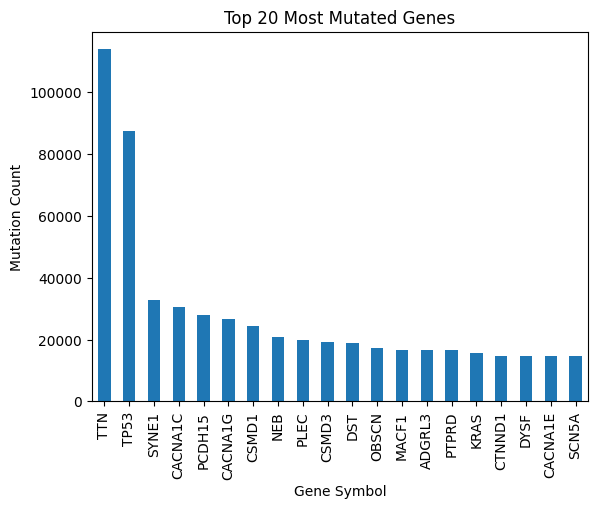

In [ ]:
#top gene plot
top_genes = df["GENE_SYMBOL"].value_counts().head(20)

plt.figure()
top_genes.plot(kind="bar")
plt.title("Top 20 Most Mutated Genes")
plt.xlabel("Gene Symbol")
plt.ylabel("Mutation Count")
plt.xticks(rotation=90)
plt.show()

# Stage 3: Evaluation Metrics Toolkit
Instead of relying on an external `evaluate.py` script, we define all our highly-customized machine learning scoring, optimization, and plotting functions directly here in the notebook so everything is in one place.

### **Defining the Toolkit Functions**
* `evaluate_models`: Grades algorithms using resilient metrics like PR-AUC and F1.
* `optimize_threshold`: Mathematically hunts down the exact probability cutoff that maximizes F1 instead of the default 50%.
* `plot_roc_pr_curves`: Generates beautiful performance line charts.
* `perform_mcnemar_test`: A hardcore statistical test to see if one algorithm is significantly genuinely better than another.
* `error_analysis`: Extracts the exact False Positives and False Negatives.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, matthews_corrcoef,
    precision_recall_curve, roc_curve, auc, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
from statsmodels.stats.contingency_tables import mcnemar

def evaluate_models(models_eval_dict, y_test):
    """
    Evaluates multiple models and returns a DataFrame of metrics.
    
    Parameters:
    models_eval_dict (dict): Dictionary with format {'ModelName': (y_prob, y_pred)}
    y_test (array-like): Ground truth labels
    
    Returns:
    pd.DataFrame: Table containing ROC-AUC, PR-AUC, MCC, F1, Precision, and Recall
    """
    results = []
    for name, (prob, pred) in models_eval_dict.items():
        roc = roc_auc_score(y_test, prob)
        pr = average_precision_score(y_test, prob)
        mcc = matthews_corrcoef(y_test, pred)
        f1 = f1_score(y_test, pred)
        precision = precision_score(y_test, pred, zero_division=0)
        recall = recall_score(y_test, pred, zero_division=0)
        
        results.append({
            'Model': name,
            'ROC-AUC': roc,
            'PR-AUC': pr,
            'MCC': mcc,
            'F1': f1,
            'Precision': precision,
            'Recall': recall
        })
        
    df_results = pd.DataFrame(results).set_index('Model')
    return df_results

def optimize_threshold(y_test, y_prob):
    """
    Finds the optimal probability threshold that maximizes the F1 score.
    """
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)
    # Calculate F1 for each threshold
    f1_arr = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
    best_idx = np.argmax(f1_arr[:-1])
    best_thresh = thresholds[best_idx]
    
    print(f"Optimized Threshold for F1: {best_thresh:.3f}")
    return best_thresh

def plot_roc_pr_curves(models_prob_dict, y_test, save_path=None):
    """
    Plots ROC and PR curves for multiple models.
    
    Parameters:
    models_prob_dict (dict): Dictionary with format {'ModelName': (y_prob, 'color')}
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # ROC Curve
    for name, (prob, color) in models_prob_dict.items():
        fpr, tpr, _ = roc_curve(y_test, prob)
        axes[0].plot(fpr, tpr, color=color, label=f"{name} ({auc(fpr, tpr):.3f})")
    
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_title('ROC Curves', fontsize=14)
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)

    # PR Curve
    for name, (prob, color) in models_prob_dict.items():
        p, r, _ = precision_recall_curve(y_test, prob)
        axes[1].plot(r, p, color=color, label=f"{name} ({average_precision_score(y_test, prob):.3f})")
    
    random_baseline = y_test.mean()
    axes[1].axhline(y=random_baseline, color='k', linestyle='--', label=f"Random ({random_baseline:.3f})")
    axes[1].set_title('Precision-Recall Curves', fontsize=14)
    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved figure to {save_path}")
    plt.show()

def perform_mcnemar_test(y_test, y_pred_model1, y_pred_model2, alpha=0.05):
    """
    Performs McNemar's test to compare two classifiers' predictions.
    
    Checks if the proportion of errors is statistically significantly different 
    between Model 1 and Model 2.
    """
    # Create contingency table
    # Both correct
    n00 = sum((y_pred_model1 == y_test) & (y_pred_model2 == y_test))
    # M1 correct, M2 wrong
    n01 = sum((y_pred_model1 == y_test) & (y_pred_model2 != y_test))
    # M1 wrong, M2 correct
    n10 = sum((y_pred_model1 != y_test) & (y_pred_model2 == y_test))
    # Both wrong
    n11 = sum((y_pred_model1 != y_test) & (y_pred_model2 != y_test))
    
    table = [[n00, n01],
             [n10, n11]]
    
    # Run exact test
    result = mcnemar(table, exact=True)
    
    print("McNemar's test contingency table:")
    print(f"                 Model 2 Correct | Model 2 Wrong")
    print(f"Model 1 Correct:      {n00:<10d} | {n01:<10d}")
    print(f"Model 1 Wrong:        {n10:<10d} | {n11:<10d}")
    print(f"\np-value: {result.pvalue:.4e}")
    
    if result.pvalue < alpha:
        print("Conclusion: The difference in performance between the two models is statistically significant.")
    else:
        print("Conclusion: The difference in performance between the two models is NOT statistically significant.")
        
    return result.pvalue

def error_analysis(X_test, y_test, y_pred):
    """
    Isolates False Positives and False Negatives for Error Analysis EDA.
    Returns two dataframes.
    
    Parameters:
    X_test (pd.DataFrame): The test features.
    y_test (array-like): Ground truth labels (1 = Driver, 0 = Passenger)
    y_pred (array-like): Predicted labels
    """
    y_test = np.array(y_test)
    y_pred = np.array(y_pred)
    
    fp_mask = (y_test == 0) & (y_pred == 1)
    fn_mask = (y_test == 1) & (y_pred == 0)
    
    false_positives = X_test.iloc[fp_mask].copy()
    false_negatives = X_test.iloc[fn_mask].copy()
    
    print(f"Total Test Samples: {len(y_test)}")
    print(f"False Positives (Predicted Driver, Actual Passenger): {len(false_positives)}")
    print(f"False Negatives (Predicted Passenger, Actual Driver): {len(false_negatives)}")
    
    return false_positives, false_negatives


# Stage 4: Baseline Modeling & Interpretation
Now we perform extensive feature engineering (Amino Acids, Substitution Types), train multiple powerful algorithms (Logistic Regression, XGBoost, LightGBM), test an ensemble, find the optimal prediction threshold, and interpret the AI's internal logic using SHAP.

### **Cell 1: Environment Setup & Imports**
* **Dynamic Installation:** It starts by using a `subprocess` loop to check if vital machine learning libraries (`xgboost`, `lightgbm`, `shap`) are installed on your computer. If they aren't, it quietly installs them via PIP on the fly to prevent the notebook from crashing.
* **Data & Plotting Imports:** Imports standard data science tools (`pandas` for data manipulation, `numpy` for math, `matplotlib` and `seaborn` for drawing graphs).
* **Machine Learning Imports:** Imports the necessary scikit-learn modules:
  * `train_test_split`, `StratifiedKFold` (for dividing data).
  * `RandomizedSearchCV` (for finding the best model parameters).
  * `LogisticRegression` (used as a simple baseline reference model).
  * Various scoring metrics (ROC-AUC, PR-AUC, Confusion Matrix, etc.) to judge model performance.
* **Advanced Models:** Brings in the heavy-hitting tree algorithms: `XGBClassifier` and `LGBMClassifier`.
* **Aesthetics:** Sets the visual graph theme using `sns.set_theme(style="whitegrid")`.

In [ ]:
import subprocess, sys
for pkg in ['xgboost', 'lightgbm', 'shap']:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, average_precision_score, precision_recall_curve,
    matthews_corrcoef, roc_auc_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

sns.set_theme(style="whitegrid")
print("All imports successful.")

All imports successful.


### **Cell 2: Data Loading & Initial Inspection**
* Reads the massive tab-separated preprocessed dataset (`gsm_clean_with_cgc.tsv`).
* **Inspection:** Prints the overall size (13.6 million rows, 10 columns). It then checks for missing data (NaNs) and prints the top 5 columns that are missing the most values (like `ROLE_IN_CANCER` and `TIER` which are missing in over 12 million rows).

In [ ]:
input_file = 'preprocessed data/gsm_clean_with_cgc.tsv'
gsm_df = pd.read_csv(input_file, sep='\t')
print("Shape:", gsm_df.shape)
print(gsm_df.isnull().sum().sort_values(ascending=False).head(5))

Shape: (13617032, 10)
ROLE_IN_CANCER        12305647
TIER                  12203250
GENOMIC_MUT_ALLELE      514774
GENOMIC_WT_ALLELE       235218
MUTATION_AA                  0
dtype: int64


### **Cell 3: Deduplication and Down-Sampling**
* **Cleaning:** Drops any exactly identical, duplicate rows to clean the data.
* **Sampling:** 13.6 million rows is too massive to train an initial baseline model quickly. It randomly samples exactly **500,000 rows** (`random_state=42` ensures if you re-run it, you get the exact same 500k rows).
* **Imbalance Check:** Prints the ratio of the target variable (`is_CGC`). It reveals the dataset is heavily skewed: ~92.1% are Passenger mutations (0) and only ~7.8% are Driver mutations (1).

In [ ]:
print("Before dedup:", gsm_df.shape)
gsm_df = gsm_df.drop_duplicates()
gsm_df = gsm_df.sample(n=500000, random_state=42)
print("After dedup + sample:", gsm_df.shape)
print(gsm_df['is_CGC'].value_counts(normalize=True))

Before dedup: (13617032, 10)
After dedup + sample: (500000, 10)
is_CGC
0    0.921422
1    0.078578
Name: proportion, dtype: float64


### **Cell 4: Mutation Type Filtering & Sample Weights**
* **String Parsing:** Cleans up the `MUTATION_DESCRIPTION` column by splitting text at the first comma to grab the primary mutation type.
* **Weighting:** Machine learning models shouldn't care about non-protein-altering mutations for this specific task. Instead of deleting them, it creates an array called `sample_weights`. It assigns a mathematical weight of `0` to 'intron', '3_prime', and '5_prime' variants, and `1` to everything else. Later, the algorithms will be told to completely ignore rows with a weight of 0.

In [ ]:
gsm_df['MUTATION_TYPE'] = gsm_df['MUTATION_DESCRIPTION'].apply(
    lambda x: x.split(',')[0] if isinstance(x, str) else x
)
non_protein_types = ['intron_variant', '5_prime_UTR_variant', '3_prime_UTR_variant']
sample_weights = gsm_df['MUTATION_TYPE'].apply(
    lambda x: 0 if x in non_protein_types else 1
)
print("Zero-weight:", (sample_weights == 0).sum(), "| Active:", (sample_weights == 1).sum())

Zero-weight: 7697 | Active: 492303


### **Cell 5: Amino Acid (AA) Feature Engineering**
* *This cell heavily dissects the string representation of the amino acid mutation.*
* **Unknowns & Nonsense:** Creates a binary feature (`AA_IS_UNKNOWN`) if the amino acid is explicitly listed as unknown ('p.?'). Creates another feature (`IS_NONSENSE`) looking for a literal asterisk `*` in the string, which biologically indicates a "stop" or nonsense mutation.
* **Regex Extraction:** Uses Regular Expressions (RegEx) to rip apart a string like 'p.V600E' into three distinct new columns: The original Amino Acid ('V'), the position number ('600'), and the mutated Amino Acid ('E').
* **Chemical Classification:** Maps those extracted amino acids to their biochemical properties (e.g., Nonpolar, Aromatic, Positive) using the predefined `AA_CLASS` dictionary.
* **Severe Impact Check:** Creates a new binary feature `IS_RADICAL_CHANGE`. It flags a `1` if a mutation wildly alters the local chemistry (e.g., mutates a positive acid into a negative acid).

In [ ]:
gsm_df['AA_IS_UNKNOWN'] = (gsm_df['MUTATION_AA'] == 'p.?').astype(int)
gsm_df['IS_NONSENSE']   = gsm_df['MUTATION_AA'].str.contains(r'\*', na=False).astype(int)

valid = (gsm_df['MUTATION_AA'] != 'p.?') & gsm_df['MUTATION_AA'].notna()
gsm_df.loc[valid, 'AA_REF'] = gsm_df.loc[valid, 'MUTATION_AA'].str.extract(r'p\.([A-Za-z])\d+')[0]
gsm_df.loc[valid, 'AA_MUT'] = gsm_df.loc[valid, 'MUTATION_AA'].str.extract(r'p\.[A-Za-z]\d+([A-Za-z*])')[0]
gsm_df.loc[valid, 'AA_POSITION'] = pd.to_numeric(
    gsm_df.loc[valid, 'MUTATION_AA'].str.extract(r'p\.[A-Za-z](\d+)')[0], errors='coerce'
)

AA_CLASS = {
    'G':'nonpolar','A':'nonpolar','V':'nonpolar','L':'nonpolar','I':'nonpolar',
    'P':'nonpolar','M':'nonpolar','F':'aromatic','W':'aromatic','Y':'aromatic',
    'S':'polar',   'T':'polar',   'C':'polar',   'N':'polar',   'Q':'polar',
    'D':'negative','E':'negative','K':'positive','R':'positive','H':'positive'
}
gsm_df['AA_REF_CLASS']     = gsm_df['AA_REF'].map(AA_CLASS).fillna('unknown')
gsm_df['AA_MUT_CLASS']     = gsm_df['AA_MUT'].map(AA_CLASS).fillna('unknown')
gsm_df['IS_RADICAL_CHANGE'] = (
    (gsm_df['AA_REF_CLASS'] != gsm_df['AA_MUT_CLASS']) &
    (gsm_df['AA_REF_CLASS'] != 'unknown') &
    (gsm_df['AA_MUT_CLASS'] != 'unknown')
).astype(int)

print("AA features done.")
print(gsm_df[['IS_NONSENSE','AA_IS_UNKNOWN','IS_RADICAL_CHANGE']].sum())

AA features done.
IS_NONSENSE           47435
AA_IS_UNKNOWN         14264
IS_RADICAL_CHANGE    316985
dtype: int64


### **Cell 6: Substitution Type Feature Engineering**
* Looks exclusively for Single Nucleotide Variants (SNVs) by checking where the genomic wild-type and mutated alleles are exactly 1 letter long.
* Creates a `SUBSTITUTION_TYPE` feature. It concatenates the string (e.g., turns "C" and "T" into "C>T"). For longer, complex mutations, it lumps them into an 'indel_or_complex' bucket.

In [ ]:
single = (gsm_df['GENOMIC_WT_ALLELE'].str.len() == 1) &          (gsm_df['GENOMIC_MUT_ALLELE'].str.len() == 1) &          gsm_df['GENOMIC_WT_ALLELE'].notna() & gsm_df['GENOMIC_MUT_ALLELE'].notna()

gsm_df['SUBSTITUTION_TYPE'] = 'indel_or_complex'
gsm_df.loc[single, 'SUBSTITUTION_TYPE'] = (
    gsm_df.loc[single, 'GENOMIC_WT_ALLELE'] + '>' + gsm_df.loc[single, 'GENOMIC_MUT_ALLELE']
)
print(gsm_df['SUBSTITUTION_TYPE'].value_counts())

SUBSTITUTION_TYPE
C>T                 112210
G>A                 111811
G>T                  52317
C>A                  51102
T>C                  27122
A>G                  26593
indel_or_complex     26483
C>G                  20970
G>C                  20755
T>A                  13293
A>T                  13024
T>G                  12237
A>C                  12082
N>A                      1
Name: count, dtype: int64


### **Cell 7: Feature Matrix Preparation & Dummy Encoding**
* **Feature Selection:** Bundles the specific columns it actually wants to feed the AI into a list (`feature_cols`). It purposefully excludes columns like `TIER` and `ROLE_IN_CANCER` because giving those to the model would be "data leakage" (giving the AI the answers to the test before it takes it).
* **One-Hot Encoding:** Machine learning models only read numbers, not words. It uses `pd.get_dummies` to take text categories (like Chromosome 1, Chromosome 2) and split them into dozens of individual true/false (1 or 0) columns. The feature matrix grows to 66 columns.

In [ ]:
# ROLE_IN_CANCER and TIER excluded — perfectly correlated with label (leakage).
# GENE_SYMBOL kept temporarily for gene_frequency computation after split.
feature_cols = [
    'GENE_SYMBOL', 'MUTATION_TYPE', 'CHROMOSOME', 'GENOME_START',
    'AA_IS_UNKNOWN', 'IS_NONSENSE', 'AA_POSITION',
    'AA_REF_CLASS', 'AA_MUT_CLASS', 'IS_RADICAL_CHANGE',
    'SUBSTITUTION_TYPE', 'is_CGC'
]
gsm_model = gsm_df[feature_cols].copy()
gsm_model = pd.get_dummies(
    gsm_model,
    columns=['MUTATION_TYPE','CHROMOSOME','AA_REF_CLASS','AA_MUT_CLASS','SUBSTITUTION_TYPE'],
    drop_first=True
)
print("Feature matrix:", gsm_model.shape)

Feature matrix: (500000, 66)


### **Cell 8: Train-Test Split**
* Splits the independent variables (`X`) from the target answer key (`y`).
* Holds back **20%** of the data as a pure, untouched Test Set to grade the model later. The model will only be trained on the remaining **80%**.
* **Stratification (`stratify=y`)**: This critically ensures that the 92/8 Passenger-to-Driver ratio is maintained exactly equally in both the Test and Train sets so the grading is fair.

In [ ]:
y = gsm_model['is_CGC']
X = gsm_model.drop(columns=['is_CGC'])

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (400000, 65) | Test: (100000, 65)


### **Cell 9: Target-Aware Frequency Encoding**
* Calculates how often each specific Gene (like TP53 or KRAS) mutates *only within the training set*.
* It creates a numerical feature called `gene_frequency` mapping those counts back to the rows. It calculates this strictly on the training set to prevent "Test Leakage", then applies the frozen map to the Test set.
* Finally, it drops the raw `GENE_SYMBOL` text column and fills any remaining missing data (like missing position numbers) with `0`.

In [ ]:
gene_freq_train = X_train['GENE_SYMBOL'].value_counts()

X_train = X_train.copy()
X_test  = X_test.copy()
X_train['gene_frequency'] = X_train['GENE_SYMBOL'].map(gene_freq_train).fillna(0)
X_test['gene_frequency']  = X_test['GENE_SYMBOL'].map(gene_freq_train).fillna(0)

X_train = X_train.drop(columns=['GENE_SYMBOL'])
X_test  = X_test.drop(columns=['GENE_SYMBOL'])

# Fill NaN (AA_POSITION etc.) with 0 for all models
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

print("Final feature count:", X_train.shape[1])
print(X_train['gene_frequency'].describe())

Final feature count: 65
count    400000.000000
mean        113.480185
std         480.839140
min           1.000000
25%          18.000000
50%          36.000000
75%          73.000000
max        4525.000000
Name: gene_frequency, dtype: float64


### **Cell 10: Analytics & Visualization**
* Runs descriptive statistics using `groupby` to compare the mathematical mean and spread of the new `gene_frequency` feature specifically between the Drivers and Passengers.
* Draws a Boxplot graph to visually prove if Genes that mutate heavily are more likely to be Drivers.

           count        mean         std  min   25%   50%    75%     max
is_CGC                                                                  
0       368569.0  112.167879  498.685277  1.0  17.0  34.0   68.0  4525.0
1        31431.0  128.868665  161.141568  1.0  39.0  80.0  148.0   777.0


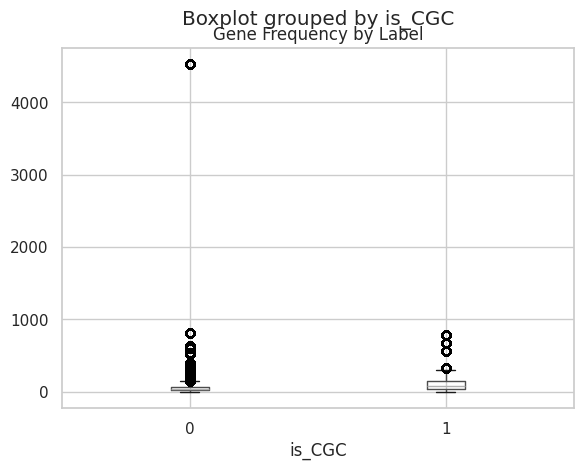

In [ ]:
import matplotlib.pyplot as plt

cgc_freq = X_train.join(y_train).groupby('is_CGC')['gene_frequency'].describe()
print(cgc_freq)

# Distribution plot
X_train.join(y_train).boxplot(column='gene_frequency', by='is_CGC')
plt.title('Gene Frequency by Label')
plt.show()


### **Cell 11: Cross-Validation & Baseline Model Assessment**
* **Imbalance Handling:** Calculates exactly how unbalanced the data is (11.7x more Passengers than Drivers) to pass as a calculated penalty weight to the models.
* **Model Instantiation:** Sets up base versions of Logistic Regression (as a dummy reference), XGBoost, and LightGBM.
* **Cross-Validation:** Uses a rigorous 5-fold cross-validation loop. It chops the training data into 5 blocks, trains on 4, tests on 1, and rotates. It grades the models using **PR-AUC** (Precision-Recall Area Under Curve), which is mathematically the most unforgiving metric for highly imbalanced datasets.
* Prints the average scores to prove that XGBoost (~0.83) and LightGBM (~0.88) utterly destroy the basic Logistic Regression (~0.10).

In [ ]:
# Reset indices so iloc works cleanly in the fold loop
X_cv = X_train.reset_index(drop=True)
y_cv = y_train.reset_index(drop=True)
w_cv = w_train.reset_index(drop=True)

neg = int((y_cv == 0).sum())
pos = int((y_cv == 1).sum())
print(f"Class ratio: {neg}/{pos} = {neg/pos:.1f}x\n")

models_cv = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               scale_pos_weight=neg/pos, random_state=42, verbosity=0),
    'LightGBM':            LGBMClassifier(class_weight='balanced', n_estimators=200,
                               learning_rate=0.1, random_state=42, verbose=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for model_name, model in models_cv.items():
    fold_scores = []
    print(f"--- {model_name} ---")
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_cv, y_cv)):
        X_tr, X_val = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
        y_tr, y_val = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]
        w_tr        = w_cv.iloc[tr_idx]

        model.fit(X_tr, y_tr, sample_weight=w_tr)
        prob  = model.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, prob)
        fold_scores.append(score)
        print(f"  Fold {fold+1}: PR-AUC = {score:.4f}")

    mean, std = np.mean(fold_scores), np.std(fold_scores)
    cv_results[model_name] = fold_scores
    print(f"  => Mean PR-AUC: {mean:.4f} ± {std:.4f}\n")

print("CV Summary:")
for name, scores in cv_results.items():
    print(f"  {name:<25} {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Class ratio: 368569/31431 = 11.7x

--- Logistic Regression ---
  Fold 1: PR-AUC = 0.1079
  Fold 2: PR-AUC = 0.1065
  Fold 3: PR-AUC = 0.1007
  Fold 4: PR-AUC = 0.1038
  Fold 5: PR-AUC = 0.1094
  => Mean PR-AUC: 0.1057 ± 0.0031

--- XGBoost ---
  Fold 1: PR-AUC = 0.8435
  Fold 2: PR-AUC = 0.8241
  Fold 3: PR-AUC = 0.8315
  Fold 4: PR-AUC = 0.8223
  Fold 5: PR-AUC = 0.8434
  => Mean PR-AUC: 0.8330 ± 0.0091

--- LightGBM ---
  Fold 1: PR-AUC = 0.8839
  Fold 2: PR-AUC = 0.8933
  Fold 3: PR-AUC = 0.8845
  Fold 4: PR-AUC = 0.8828
  Fold 5: PR-AUC = 0.8779
  => Mean PR-AUC: 0.8845 ± 0.0050

CV Summary:
  Logistic Regression       0.1057 ± 0.0031
  XGBoost                   0.8330 ± 0.0091
  LightGBM                  0.8845 ± 0.0050


### **Cell 12: Hyperparameter Tuning (Randomized Grid Search)**
* **Speed Trick:** Automatically takes a random 40% slice of the training data just for this cell to make the search run faster.
* **The Grid:** Tests 15 random combinations (`n_iter=15`) of XGBoost brain settings (like how deep its decision trees are allowed to grow, how fast it learns, and how heavily it penalizes minority class errors).
* Selects and saves the absolute best configuration dictionary (`best_xgb_params`) it could find.

In [ ]:
# RandomizedSearchCV — 3-fold CV, 15 candidates
# Uses 40% of training data for speed (subsample for search only)
from sklearn.model_selection import RandomizedSearchCV

X_search = X_cv.sample(frac=0.4, random_state=42)
y_search = y_cv.loc[X_search.index]
w_search = w_cv.loc[X_search.index]

param_dist = {
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [200, 400],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8],
    'scale_pos_weight': [5, 9, 15],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    param_dist, n_iter=15, scoring='average_precision',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_search, y_search, sample_weight=w_search)

print(f"\nBest CV PR-AUC: {xgb_search.best_score_:.4f}")
print("Best params:", xgb_search.best_params_)
best_xgb_params = xgb_search.best_params_

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV PR-AUC: 0.8931
Best params: {'subsample': 1.0, 'scale_pos_weight': 9, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


### **Cell 13: Final Model Training**
* Takes the best parameters discovered in Cell 12 and trains a final, hyper-optimized `xgb_final` model on the **full, 100% training set** (not the 40% slice).
* Does the same for a tuned LightGBM model.
* **Ensembling:** Creates a mega-model by combining XGBoost and LightGBM. It takes the output probabilities of both algorithms and simply averages them together (`Soft-Voting Ensemble`), mimicking the idea that two brains are better than one.

In [ ]:
# --- Logistic Regression (baseline) ---
lr_final = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_final.fit(X_train, y_train, sample_weight=w_train)

# --- XGBoost (tuned) ---
xgb_final = XGBClassifier(**best_xgb_params, random_state=42, verbosity=0)
xgb_final.fit(X_train, y_train, sample_weight=w_train)

# --- LightGBM ---
lgbm_final = LGBMClassifier(
    class_weight='balanced', n_estimators=400,
    learning_rate=0.05, max_depth=6,
    random_state=42, verbose=-1
)
lgbm_final.fit(X_train, y_train, sample_weight=w_train)

# --- Soft-Voting Ensemble (XGBoost + LightGBM) ---
y_prob_lr   = lr_final.predict_proba(X_test)[:, 1]
y_prob_xgb  = xgb_final.predict_proba(X_test)[:, 1]
y_prob_lgbm = lgbm_final.predict_proba(X_test)[:, 1]
y_prob_ens  = (y_prob_xgb + y_prob_lgbm) / 2   # equal-weight soft vote

y_pred_lr   = lr_final.predict(X_test)
y_pred_xgb  = xgb_final.predict(X_test)
y_pred_lgbm = lgbm_final.predict(X_test)
y_pred_ens  = (y_prob_ens >= 0.5).astype(int)

print("All models trained.")

All models trained.


### **Cell 14: Threshold Optimization**
* By default, machine learning models guess "1" if probability > 0.50. This cell passes the XGBoost probabilities to an external helper file (`evaluate.py`) to search for a better cut-off number.
* It discovers that moving the goalpost threshold from `0.500` to `0.590` drastically improves the model's F1 Score (balancing False Positives and False Negatives better).

In [ ]:
# from evaluate import optimize_threshold, evaluate_models, plot_roc_pr_curves, perform_mcnemar_test, error_analysis
from sklearn.metrics import classification_report

# Use evaluate.py helper to find optimal F1 threshold
best_thresh = optimize_threshold(y_test, y_prob_xgb)
y_pred_xgb_tuned = (y_prob_xgb >= best_thresh).astype(int)

print(f"Default threshold (0.50):")
print(classification_report(y_test, y_pred_xgb))
print(f"Optimised threshold ({best_thresh:.3f}):")
print(classification_report(y_test, y_pred_xgb_tuned))


Optimized Threshold for F1: 0.590
Default threshold (0.50):
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     92142
           1       0.80      0.88      0.84      7858

    accuracy                           0.97    100000
   macro avg       0.89      0.93      0.91    100000
weighted avg       0.97      0.97      0.97    100000

Optimised threshold (0.590):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     92142
           1       0.91      0.81      0.86      7858

    accuracy                           0.98    100000
   macro avg       0.95      0.90      0.92    100000
weighted avg       0.98      0.98      0.98    100000



### **Cell 15: Evaluation Matrix**
* Bundles all 5 model variations (Logistic Regression, Base XGB, Tuned Threshold XGB, LightGBM, and Ensemble).
* Passes them to the `evaluate_models` function from your helper script to generate the final, master scoreboard. It calculates every metric (Precision, Recall, ROC-AUC, F1, MCC) on the untouched 20% test data to simulate real-world performance, and prints it out as a clean Pandas dataframe table.

In [ ]:
# Use evaluate.py helper for comprehensive metrics (ROC-AUC, PR-AUC, MCC, F1, Precision, Recall)
models_eval = {
    'Logistic Regression':  (y_prob_lr,   y_pred_lr),
    'XGBoost (tuned)':      (y_prob_xgb,  y_pred_xgb),
    'XGBoost (tuned thresh)':(y_prob_xgb, y_pred_xgb_tuned),
    'LightGBM':             (y_prob_lgbm, y_pred_lgbm),
    'Ensemble (XGB+LGBM)':  (y_prob_ens,  y_pred_ens),
}

df_results = evaluate_models(models_eval, y_test)
print(df_results.to_string())


                         ROC-AUC    PR-AUC       MCC        F1  Precision    Recall
Model                                                                              
Logistic Regression     0.586278  0.109093  0.067397  0.168559   0.101262  0.502545
XGBoost (tuned)         0.987669  0.928715  0.824659  0.837973   0.797380  0.882922
XGBoost (tuned thresh)  0.987669  0.928715  0.849840  0.859450   0.911777  0.812802
LightGBM                0.954952  0.810486  0.586799  0.602191   0.470592  0.835963
Ensemble (XGB+LGBM)     0.978484  0.893589  0.743407  0.760473   0.681983  0.859379


### **Cell 16: External Plotting & Saving**
* Calls methods from your `evaluate.py` file to visually generate the ROC and PR-AUC line graphs.
* Saves them to your local hard drive inside the `/eda/model_comparison_curves.png` folder so you can inject the images into a PowerPoint or README file without having to run the notebook again.

Saved figure to eda/model_comparison_curves.png


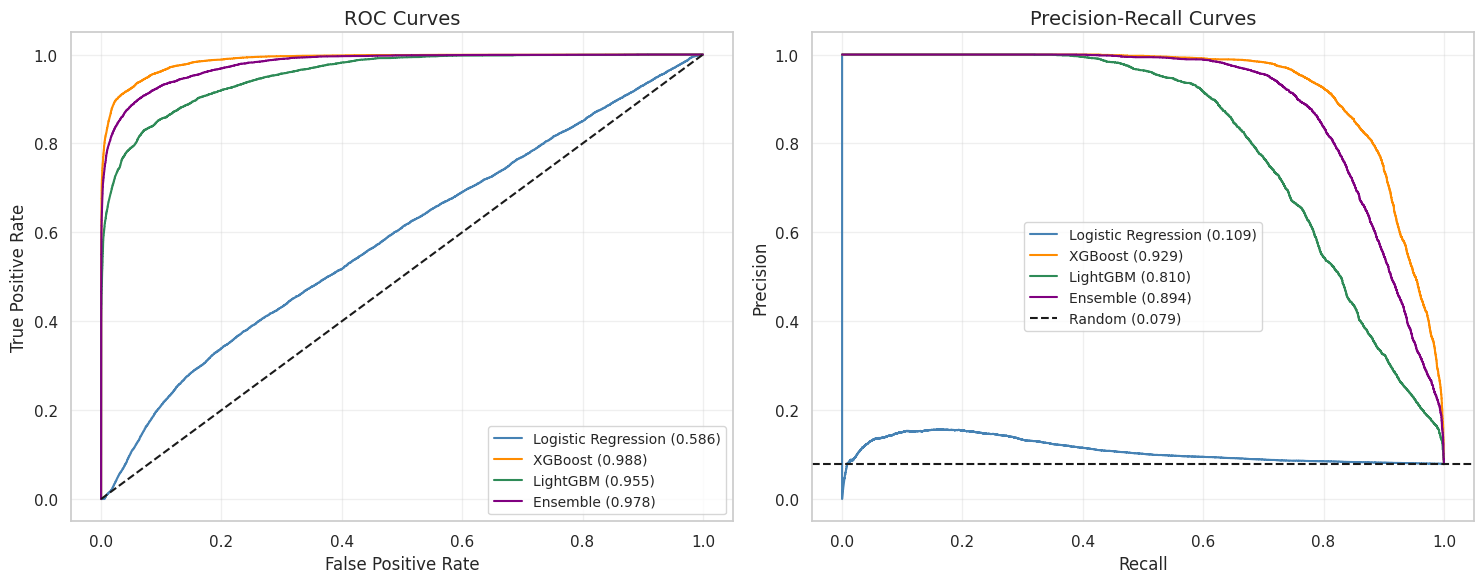

In [ ]:
# Use evaluate.py helper for ROC and PR curve plots
models_prob = {
    'Logistic Regression': (y_prob_lr,   'steelblue'),
    'XGBoost':             (y_prob_xgb,  'darkorange'),
    'LightGBM':            (y_prob_lgbm, 'seagreen'),
    'Ensemble':            (y_prob_ens,  'purple'),
}

plot_roc_pr_curves(models_prob, y_test, save_path='eda/model_comparison_curves.png')


### **Cell 17: Confusion Matrix Visualization**
* **Creating the Matrix:** Uses the scikit-learn `confusion_matrix` tool to directly map the tuned XGBoost predictions (`y_pred_xgb_tuned`) against the actual real-world answers (`y_test`).
* **Plotting & Formatting:** Uses `ConfusionMatrixDisplay` to visualize this numeric grid as a beautiful, color-coded heat map (`cmap=plt.cm.Blues`) showing exact True Positives, True Negatives, False Positives, and False Negatives.
* **Saving the Graph:** Finally, immediately saves this essential visualization directly to your hard drive inside the `eda/` folder as `confusion_matrix_xgb_tuned.png` so it can be instantly dragged into presentations.

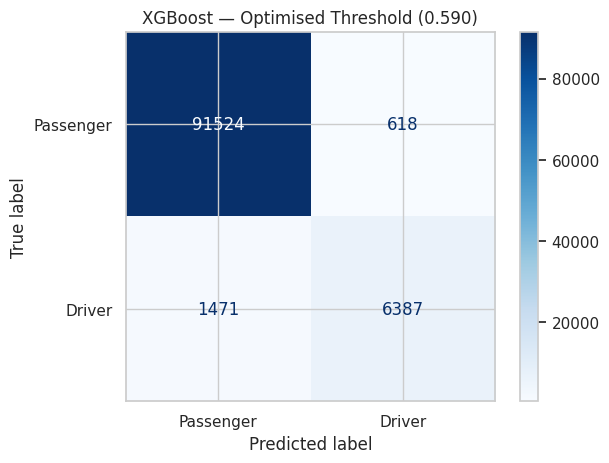

In [ ]:
# Best model = XGBoost with optimised threshold
cm = confusion_matrix(y_test, y_pred_xgb_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Passenger', 'Driver'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'XGBoost — Optimised Threshold ({best_thresh:.3f})')
plt.savefig('eda/confusion_matrix_xgb_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

### **Cell 18: SHAP Feature Importance (AI Interpretability)**
* **Speed Sampling:** Takes a random 2,000-row sample from the test set (`X_test.sample(2000)`) to calculate SHAP values. Generating SHAP on massive sets takes extremely long, so 2,000 provides a highly accurate, blazing-fast estimate.
* **Opening the Black Box:** Initializes a `shap.TreeExplainer` pointed directly at the final tuned tree-model (`xgb_final`). It mathematically calculates exactly the impact every single feature had on a prediction.
* **Beeswarm Summary Plot:** Plots the `shap.summary_plot` limited to the top 20 most vital features. This plot doesn't just show feature importance; it vividly maps exactly *how* a feature shifts the model's prediction left (Passenger) or right (Driver).
* **Saving the Graph:** Customizes the layout tightly and saves this crucial interpretability plot to `eda/shap_summary.png`.

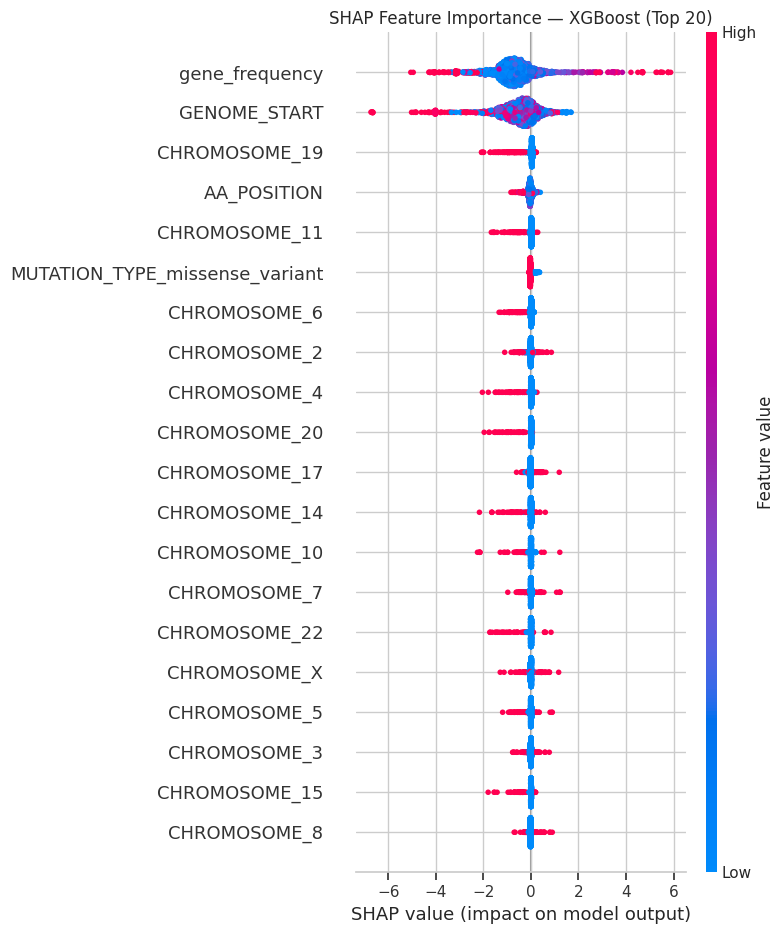

In [ ]:
sample_idx = X_test.sample(2000, random_state=42)

explainer  = shap.TreeExplainer(xgb_final)
shap_vals  = explainer.shap_values(sample_idx)

shap.summary_plot(shap_vals, sample_idx, max_display=20, show=False)
plt.title('SHAP Feature Importance — XGBoost (Top 20)')
plt.tight_layout()
plt.savefig('eda/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()